In [1]:
from AllModelFunctions import import_models_quickload, models_in_interval
import matplotlib.pyplot as plt
import matplotlib
from PyAstronomy import pyasl
from AllModelFunctions import extract_spectrum_within_range
import numpy as np

In [2]:
models = import_models_quickload('Milkyway')

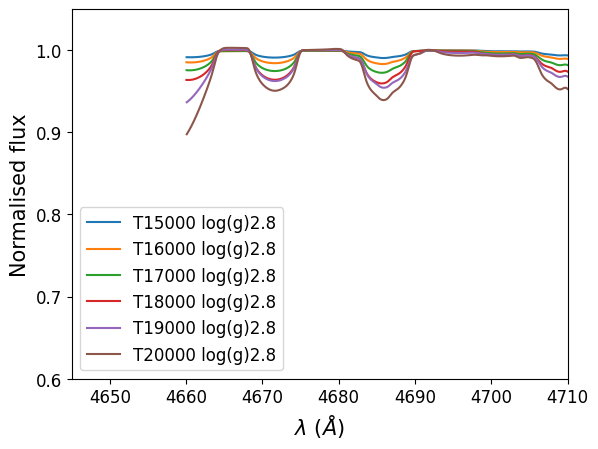

In [11]:
# matplotlib.use('Qt5Agg')

selection = models_in_interval(models, T1=15000, T2=20000, log_g1=2.7, log_g2=2.8)
plt.figure()

for model in selection.values():
    # Get flux and wavelength
    wav_model = np.array(model['WAVELENGTH'])
    flux_model = np.array(model['FLUX'])

    if max(flux_model) < 4:
        wav_model, flux_model = extract_spectrum_within_range(np.array(wav_model), np.array(flux_model), 4650, 4710)

        # Apply doppler broadening
        wav_model, flux_model = pyasl.equidistantInterpolation(wav_model, flux_model, "2x")
        flux_model = pyasl.rotBroad(wav_model, flux_model, 0.0, 200)

        plt.plot(wav_model + 10, flux_model, label=f"T{model['Teff']} log(g){model['log(g)']}")

plt.legend(fontsize=12)
plt.xlabel(r"$\lambda$ ($\AA$)", fontsize=15)
plt.ylabel("Normalised flux", fontsize=15)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.ylim(0.6, 1.05)
plt.xlim(4645, 4710)
plt.show()

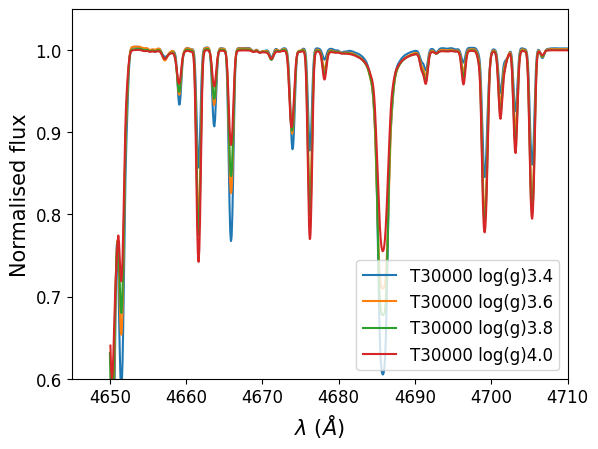

In [9]:
selection = models_in_interval(models, T1=30000, T2=30000, log_g1=3, log_g2=4)
plt.figure()

for model in selection.values():
    # Get flux and wavelength
    wav_model = np.array(model['WAVELENGTH'])
    flux_model = np.array(model['FLUX'])

    if max(flux_model) < 4:
        wav_model, flux_model = extract_spectrum_within_range(np.array(wav_model), np.array(flux_model), 4650, 4710)

        # Apply doppler broadening
        wav_model, flux_model = pyasl.equidistantInterpolation(wav_model, flux_model, "2x")
        # flux_model = pyasl.rotBroad(wav_model, flux_model, 0.0, 10)

        plt.plot(wav_model, flux_model, label=f"T{model['Teff']} log(g){model['log(g)']}")

plt.legend(fontsize=12)
plt.xlabel(r"$\lambda$ ($\AA$)", fontsize=15)
plt.ylabel("Normalised flux", fontsize=15)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.ylim(0.6, 1.05)
plt.xlim(4645, 4710)
plt.show()